## Partie 1 : modèle MIL Gated Attention

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [2]:
import sys, torch
print(f"Python  : {sys.version}")
print(f"Torch   : {torch.__version__}")
print(f"Torch path : {torch.__file__}")

Python  : 3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:02) [GCC 14.3.0]
Torch   : 2.11.0+cu130
Torch path : /shared/home/myoussef/.local/lib/python3.14/site-packages/torch/__init__.py


In [3]:
torch.cuda.is_available()

True

In [4]:
torch.cuda.get_device_name()

'NVIDIA L40S'

In [5]:
torch.cuda.device_count()

1

In [6]:
print(torch.cuda.mem_get_info())  # (free, total)

(47210430464, 47665709056)


In [7]:
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/transformers-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/torch-*.dist-info

#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer
#!rm -rf /shared/home/myoussef/.local/lib/python3.12/site-packages/bacformer-*.dist-info

In [8]:
#!/shared/software/miniconda/envs/python-3.11.2/bin/python -m pip install --no-cache-dir "transformers==4.57.5" bacformer

In [9]:
#!pip uninstall transformers -y

#!pip show transformers

#!pip install transformers==4.40.0 --break-system-packages

In [10]:
#!pip3 install transformers

In [11]:
#!pip3 install pandas
#!pip3 install biopython
#!pip3 install bacformer

In [12]:
import transformers, torch
print("transformers:", transformers.__version__)
print("transformers path:", transformers.__file__)
print("torch path:", torch.__file__)
from transformers import PreTrainedModel

transformers: 5.5.0
transformers path: /shared/home/myoussef/.local/lib/python3.14/site-packages/transformers/__init__.py
torch path: /shared/home/myoussef/.local/lib/python3.14/site-packages/torch/__init__.py


In [13]:
print(torch.__version__)
print(transformers.__version__)

2.11.0+cu130
5.5.0


In [14]:
import os, gzip
from pathlib import Path
from collections import Counter, defaultdict
import glob
import random

import numpy as np
import pandas as pd
from Bio import SeqIO

from transformers import AutoModel
from bacformer.pp import protein_seqs_to_bacformer_inputs
#from bacformer.modeling import SPECIAL_TOKENS_DICT

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_recall_curve)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [15]:
# bacformer/pp/preprocess.py
# chnagement de extract_protein_info_from_genbank() et preprocess_genome_assembly() # pas de accession !

import gzip
from typing import Any

import pandas as pd
from Bio import SeqIO


def extract_protein_info_from_genbank(filepath: str):
    """
    Extract protein details from a GenBank file (.gbff/.gbk and optionally .gz) and return a DataFrame.

    Returns a DataFrame with columns used by Bacformer preprocessing.
    """
    if filepath.endswith(".gz"):
        handle = gzip.open(filepath, "rt")
    else:
        handle = open(filepath, "r")

    records = SeqIO.parse(handle, "genbank")
    data = []

    contig_idx = 0
    for record in records:
        genome_name = record.annotations.get("organism", None)

        for feature in record.features:
            if feature.type != "CDS":
                continue

            translation = feature.qualifiers.get("translation", [None])[0]
            if translation is None:
                continue

            gene_name = feature.qualifiers.get("gene", [None])[0]
            locus_tag = feature.qualifiers.get("locus_tag", [None])[0]
            protein_id = feature.qualifiers.get("protein_id", [None])[0]

            start = int(feature.location.start)
            end = int(feature.location.end)

            data.append(
                {
                    "strain_name": genome_name,
                    "gene_name": gene_name,
                    "protein_name": locus_tag,
                    "start": start,
                    "end": end,
                    "protein_id": protein_id,
                    "contig_idx": contig_idx,
                    "protein_sequence": translation,
                }
            )

        contig_idx += 1

    handle.close()
    return pd.DataFrame(data)

def extract_protein_info_from_gff(filepath):
    """
    Extract protein details from a GFF file (.gff or .gff.gz) into a pandas DataFrame.

    Args:
        filepath (str): Path to the GFF file.

    Returns
    -------
        pd.DataFrame: A DataFrame where each row is a gene, with columns for gene details.
    """
    genes = []

    # Open the file based on its extension
    if filepath.endswith(".gz"):
        open_func = gzip.open
        mode = "rt"  # Read as text
    else:
        open_func = open
        mode = "r"

    with open_func(filepath, mode) as file:
        for line in file:
            if line.startswith("#"):
                # # Extract assembly ID from the header
                # if line.startswith("##sequence-region"):
                #     assembly_id = line.split()[1]
                continue

            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue  # Skip malformed lines

            feature_type = parts[2]
            if feature_type != "CDS":
                continue  # Focus only on genes

            seqid = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            attributes = parts[8]

            # Parse attributes
            attr_dict = {}
            for attr in attributes.split(";"):
                if "=" in attr:
                    key, value = attr.split("=", 1)
                    attr_dict[key] = value

            # Extract specific fields
            gene_name = attr_dict.get("gene", None)
            locus_tag = attr_dict.get("locus_tag", None)
            protein_id = attr_dict.get("protein_id", None)

            # Append gene info to the list
            genes.append(
                {
                    "seqid": seqid,
                    "start": start,
                    "end": end,
                    "strand": strand,
                    "gene_name": gene_name if gene_name is not None else locus_tag,
                    "locus_tag": locus_tag,
                    "protein_id": protein_id,
                }
            )

    # Convert to DataFrame
    df = pd.DataFrame(genes)
    return df

def preprocess_genome_assembly(filepath: str) -> dict[str, Any]:
    """
    Preprocess a genome assembly file (GenBank or GFF) to extract protein information for Bacformer input.
    Modified: does NOT rely on accession fields; accepts .gbk/.gbk.gz too.
    """
    if filepath.endswith((".gbff", ".gbff.gz", ".gbk", ".gbk.gz")):
        df = extract_protein_info_from_genbank(filepath)
    elif filepath.endswith((".gff", ".gff.gz")):
        df = extract_protein_info_from_gff(filepath)
    else:
        raise ValueError("Unsupported file format. Use .gbff/.gbk or .gff (optionally .gz).")

    if df.empty:
        raise ValueError("No protein translations found in file (empty CDS/translation set).")

    # groupby contig and aggregate protein information
    df = (
        df.groupby(["strain_name", "contig_idx"])[
            ["gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    # sort by contig_idx
    df = df.sort_values(by="contig_idx", ascending=True)

    # aggregate all contigs in the genome
    df = (
        df.groupby(["strain_name"])[
            ["contig_idx", "gene_name", "protein_name", "start", "end", "protein_id", "protein_sequence"]
        ]
        .agg(list)
        .reset_index()
    )

    return dict(df.iloc[0])

In [ ]:
INPUT_DIR = "genomes_gbff"
OUT_DIR = "embeddings_out"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda:0" #if torch.cuda.is_available() else "cpu"

# Charger le modèle
model = AutoModel.from_pretrained(
    "macwiatrak/bacformer-masked-complete-genomes", trust_remote_code=True
).to(device).eval().to(torch.bfloat16)

# vérifier que le .pt existe et est OK 
def output_is_valid(out_path: str) -> bool:
    if not os.path.isfile(out_path):
        return False
    try:
        obj = torch.load(out_path)
        if "last_hidden_state" not in obj:
            return False
        t = obj["last_hidden_state"]
        if not torch.is_tensor(t):
            return False
        if t.ndim != 3:
            return False
        return True
    except Exception:
        return False

# Boucle sur les fichiers gbff
files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.gbff")))
print("Nb fichiers:", len(files))

for fp in files:
    genome_id = os.path.splitext(os.path.basename(fp))[0]
    
    # vérifier si déjà généré
    out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    if output_is_valid(out_path):
        print("Skipping (already done):", genome_id)
        continue
    
    print("Processing:", genome_id)

    genome_info = preprocess_genome_assembly(filepath=fp)
    protein_seqs = genome_info["protein_sequence"]

    inputs = protein_seqs_to_bacformer_inputs(
        protein_seqs,
        device=device,
        batch_size=128,
        max_n_proteins=6000,
    )

    # 3) Bacformer: embeddings contextualisés
    with torch.no_grad():
        outputs = model(**inputs, return_dict=True)

    last_hidden = outputs["last_hidden_state"]  # (1, seq_len, dim)
    # Pour un "genome embedding" par moyenne de seq_len
    #genome_emb = last_hidden.mean(dim=1)

    # 4) Sauvegarde simple
    #out_path = os.path.join(OUT_DIR, f"{genome_id}.pt")
    torch.save(
        {
            "genome_id": genome_id,
            "n_proteins": len(protein_seqs),
            "last_hidden_state": last_hidden.cpu(),  # embeddings contextualisés
            #"genome_embedding_mean": genome_emb.cpu(),
        },
        out_path,
    )

    print("  saved:", out_path, "| last_hidden_state:", tuple(last_hidden.shape))

In [16]:
x = torch.load("./embeddings_out/562.90695.pt")["last_hidden_state"]
print(x[0, :7, :7])  # 7 protéines/tokens × 7 dimensions

tensor([[ 0.1187,  0.2168, -0.1099,  0.1641, -0.1216,  0.0041, -0.4629],
        [-0.0398,  0.3574,  0.1108,  0.2812, -0.0366,  0.2119, -0.3711],
        [ 0.0820,  0.2080,  0.0184,  0.3359, -0.3223, -0.1348, -0.3984],
        [-0.1787,  0.1357,  0.1641,  0.3691, -0.2559,  0.0439, -0.0371],
        [-0.0199,  0.1318, -0.0327,  0.1455, -0.1025,  0.4668, -0.2773],
        [ 0.1914,  0.2812, -0.4375, -0.0884,  0.0767,  0.4609, -0.2012],
        [ 0.2363,  0.0918, -0.2354, -0.0442,  0.2256,  0.1846, -0.0081]],
       dtype=torch.bfloat16)


In [17]:
#Si val AUC/F1 baisse alors que train loss baisse → overfit → dropout↑ ou hidden↓
#si le modèle overfit (train monte, val baisse) → baisse à 64
#si le modèle sous-apprends (train et val mauvais) → monte à 256

In [18]:
PT_DIR      = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
SEED       = 42
BATCH_SIZE = 8
EPOCHS     = 50
LR         = 3e-4
ATTN_DIM   = 128
HIDDEN     = 128
DROPOUT    = 0.3
 
device = "cuda" if torch.cuda.is_available() else "cpu"
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(SEED)
print(f"Seed fixée à {SEED} | device : {device}")

Seed fixée à 42 | device : cuda


In [19]:
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"] = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)

    bad = df[(df["Resistant"] + df["Susceptible"]) != 1]
    if len(bad) > 0:
        print("Incoherent label rows (Resistant+Susceptible != 1):", len(bad))
        print(bad.head())

    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))

id_to_y = load_labels(LABELS_PATH)

# Charger tous les fichiers
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
n_proteins_list = []

print(f"\n Fichiers .pt trouvés   : {len(all_files)}")
print(f"   Avec label matching   : {len(matched)}")
print(f"   Sans label (ignorés)  : {len(all_files) - len(matched)}")

# Résistants / Sensibles parmi les labellisés
matched_labels  = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
n_resistant     = int(matched_labels.sum())
n_susceptible   = int(len(matched_labels) - n_resistant)
ratio           = matched_labels.mean()

print(f"\n Parmi les {len(matched)} génomes labellisés :")
print(f"   Résistants  (1) : {n_resistant}  ({ratio:.1%})")
print(f"   Sensibles   (0) : {n_susceptible}  ({1-ratio:.1%})")
if ratio < 0.10:
    print("    Déséquilibre SÉVÈRE")
elif ratio < 0.20:
    print("    Déséquilibre MODÉRÉ")
else:
    print("    Distribution acceptable")

# Stats sur la taille des génomes (nombre de protéines)
for fp in matched[:50]:
    _, X = load_pt(fp)
    n_proteins_list.append(X.shape[0])

print(f"\n Taille des génomes (nb protéines) sur 50 échantillons :")
print(f"   Min    : {np.min(n_proteins_list)}")
print(f"   Max    : {np.max(n_proteins_list)}")
print(f"   Moyenne: {np.mean(n_proteins_list):.0f}")
print(f"   Médiane: {np.median(n_proteins_list):.0f}")
print(f"\n     Dimension embedding (D) : {load_pt(matched[0])[1].shape[1]}")


 Fichiers .pt trouvés   : 1066
   Avec label matching   : 907
   Sans label (ignorés)  : 159

 Parmi les 907 génomes labellisés :
   Résistants  (1) : 53  (5.8%)
   Sensibles   (0) : 854  (94.2%)
    Déséquilibre SÉVÈRE

 Taille des génomes (nb protéines) sur 50 échantillons :
   Min    : 4426
   Max    : 5358
   Moyenne: 4935
   Médiane: 4973

     Dimension embedding (D) : 480


In [20]:
class GenomeMILDataset(Dataset):
    def __init__(self, pt_dir, id_to_y):
        self.id_to_y = id_to_y
        files = sorted(glob.glob(os.path.join(pt_dir, "*.pt")))
        self.files = [fp for fp in files if load_pt(fp)[0] in id_to_y]
        if len(self.files) == 0:
            raise ValueError("Aucun .pt matché avec les labels.")
 
    def __len__(self):
        return len(self.files)
 
    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid
    
def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)
 
dataset = GenomeMILDataset(PT_DIR, id_to_y)
n = len(dataset)
 
# Labels dans l'ordre du dataset
all_labels = np.array([id_to_y[load_pt(dataset.files[i])[0]] for i in range(n)])

# Diagnostic dataset
print(f"   Total : {n} génomes")
print(f"   Résistants : {all_labels.sum()} ({all_labels.mean():.1%})")
 

   Total : 907 génomes
   Résistants : 53 (5.8%)


In [21]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
 
    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()
    
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False
        self.best_state = None
 
    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                
class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=128, hidden=128, dropout=0.3):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            #nn.Linear(hidden, hidden // 2),
            #nn.ReLU(),
            #nn.Linear(hidden // 2, 1),
            nn.Linear(hidden, 1),
        )
 
    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1) # score d'attention pour chaque protéine
        
        # ignore padding for softmax
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1) #poids appris par le modèle pour chaque protéine
        
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1) # agrégation pondérée
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha

X0, _, _ = dataset[0]
emb_dim  = X0.shape[1]
model    = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Modèle initialisé")
print(f"   emb_dim       : {emb_dim}")
print(f"   Nb paramètres : {n_params:,}")
print(f"   Loss          : FocalLoss (alpha=0.85, gamma=2.0)")
print(f"   Optimiseur    : AdamW (lr={LR}, wd=1e-2)")
 

 Modèle initialisé
   emb_dim       : 480
   Nb paramètres : 185,218
   Loss          : FocalLoss (alpha=0.85, gamma=2.0)
   Optimiseur    : AdamW (lr=0.0003, wd=1e-2)


In [22]:
def find_best_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s      = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1s)
    return float(thresholds[best_idx])
 
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    auc    = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {"acc": acc, "f1": f1, "auc": auc}
 
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)
 
@torch.no_grad()
def evaluate(model, loader, criterion=None, threshold=0.5):
    if criterion is None:
        criterion = FocalLoss(alpha=0.85, gamma=2.0) 
    model.eval()
    all_y, all_prob, total_loss, n_batches = [], [], 0.0, 0
    for Xpad, mask, y, _ in loader:
        Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
        logits, _     = model(Xpad, mask)
        total_loss   += float(criterion(logits, y).item())
        all_prob.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())
        n_batches += 1
    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_prob)
    m      = compute_metrics(y_true, y_prob, threshold)
    m["loss"] = total_loss / max(n_batches, 1)
    return m

In [23]:
# Avec Cross-validation stratifiée 5-fold

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []

print(f"Cross-validation 5-fold stratifiée")
print(f"   Total génomes : {n} | Résistants : {all_labels.sum()} ({all_labels.mean():.1%})\n")
print(f"{'Fold':>4} | {'val_auc':>7} {'val_f1':>6} | {'te_auc':>7} {'te_f1':>6} {'te_acc':>6} | {'seuil':>5} | {'te_f1_opt':>9}")
print("-" * 75)

for fold, (train_val_idx, test_idx) in enumerate(skf.split(np.arange(n), all_labels), 1):
    
    fold_history = {
        "train_loss": [],
        "val_auc":    [],
        "val_f1":     [],
        "test_auc":   [],
        "test_f1":    [],
    }

    # Split train / val / test
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=0.1/0.9,
        stratify=all_labels[train_val_idx], random_state=SEED
    )

    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)
    test_ds  = Subset(dataset, test_idx)

    # Oversampling sur le train
    train_labels   = all_labels[train_idx]
    class_counts   = np.bincount(train_labels)
    sample_weights = 1.0 / class_counts[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(train_labels),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,   collate_fn=mil_collate)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,     collate_fn=mil_collate)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,     collate_fn=mil_collate)

    # Nouveau modèle pour chaque fold
    fold_model = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
    fold_criterion    = FocalLoss(alpha=0.85, gamma=2.0)
    fold_optimizer    = optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-2)
    fold_scheduler    = optim.lr_scheduler.ReduceLROnPlateau(fold_optimizer, mode="max", factor=0.5, patience=2)
    fold_early_stop   = EarlyStopping(patience=5, min_delta=0.001)

    # Entraînement
    for epoch in range(1, EPOCHS + 1):
        # train
        fold_model.train()
        epoch_loss = 0.0     
        n_batches  = 0 
        for Xpad, mask, y, _ in train_loader:
            Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
            fold_optimizer.zero_grad()
            logits, _ = fold_model(Xpad, mask)
            loss = fold_criterion(logits, y)
            loss.backward()
            fold_optimizer.step()
            epoch_loss += loss.item()  
            n_batches  += 1 
                
        train_loss = epoch_loss / max(n_batches, 1)

        # val
        val_m  = evaluate(fold_model, val_loader)
        test_m = evaluate(fold_model, test_loader)
        
        
        fold_history["train_loss"].append(epoch_loss / max(n_batches, 1))  
        fold_history["val_auc"].append(val_m["auc"]   or 0)                
        fold_history["val_f1"].append(val_m["f1"]    or 0)                 
        fold_history["test_auc"].append(test_m["auc"]  or 0)               
        fold_history["test_f1"].append(test_m["f1"]   or 0)     
            
        score  = 0.5 * (val_m["auc"] or 0) + 0.5 * (val_m["f1"] or 0)
        fold_scheduler.step(score)
        fold_early_stop(score, fold_model)

        if fold_early_stop.stop:
            break

    # Restore best + évaluation finale
    if fold_early_stop.best_state:
        fold_model.load_state_dict(fold_early_stop.best_state)

    val_y,  val_prob  = get_probs(fold_model, val_loader)
    test_y, test_prob = get_probs(fold_model, test_loader)

    best_thr  = find_best_threshold(val_y, val_prob)
    val_m     = compute_metrics(val_y,  val_prob, threshold=0.5)
    test_def  = compute_metrics(test_y, test_prob, threshold=0.5)
    test_opt  = compute_metrics(test_y, test_prob, threshold=best_thr)

    print(
        f"{fold:>4} | {val_m['auc'] or 0:>7.3f} {val_m['f1']:>6.3f} | "
        f"{test_def['auc'] or 0:>7.3f} {test_def['f1']:>6.3f} {test_def['acc']:>6.3f} | "
        f"{best_thr:>5.2f} | {test_opt['f1']:>9.3f}"
    )

    fold_results.append({
        "fold":        fold,
        "val_auc":     val_m["auc"]     or 0,
        "val_f1":      val_m["f1"],
        "test_auc":    test_def["auc"]  or 0,
        "test_f1":     test_def["f1"],
        "test_f1_opt": test_opt["f1"],
        "threshold":   best_thr,
        "n_test":      len(test_y),
        "n_resistant_test": int(test_y.sum()),
        "history":     fold_history,
    })

# Résumé final
print("-" * 75)
metrics = ["val_auc", "val_f1", "test_auc", "test_f1", "test_f1_opt"]
print(f"\n Résumé sur 5 folds :")
for m in metrics:
    vals = [r[m] for r in fold_results]
    print(f"   {m:>12} : {np.mean(vals):.3f} ± {np.std(vals):.3f}")

print(f"\n   Résistants par fold test : {[r['n_resistant_test'] for r in fold_results]}")
print(f"   Seuils optimaux          : {[round(r['threshold'],2) for r in fold_results]}")

# Garder le modèle du meilleur fold
best_fold_idx = np.argmax([r["test_f1_opt"] for r in fold_results])
best_fold     = fold_results[best_fold_idx]
print(f"\n Meilleur fold : {best_fold['fold']} "
      f"(test_f1_opt={best_fold['test_f1_opt']:.3f})")

Cross-validation 5-fold stratifiée
   Total génomes : 907 | Résistants : 53 (5.8%)

Fold | val_auc val_f1 |  te_auc  te_f1 te_acc | seuil | te_f1_opt
---------------------------------------------------------------------------
   1 |   1.000  1.000 |   0.895  0.667  0.967 |  0.54 |     0.667
   2 |   0.916  0.800 |   0.866  0.571  0.951 |  0.59 |     0.556
   3 |   1.000  0.909 |   0.945  0.667  0.972 |  0.61 |     0.333
   4 |   1.000  0.909 |   0.864  0.533  0.961 |  0.68 |     0.462
   5 |   0.945  0.727 |   0.934  0.762  0.972 |  0.61 |     0.700
---------------------------------------------------------------------------

 Résumé sur 5 folds :
        val_auc : 0.972 ± 0.035
         val_f1 : 0.869 ± 0.095
       test_auc : 0.901 ± 0.034
        test_f1 : 0.640 ± 0.080
    test_f1_opt : 0.543 ± 0.135

   Résistants par fold test : [11, 11, 10, 10, 11]
   Seuils optimaux          : [0.54, 0.59, 0.61, 0.68, 0.61]

 Meilleur fold : 5 (test_f1_opt=0.700)


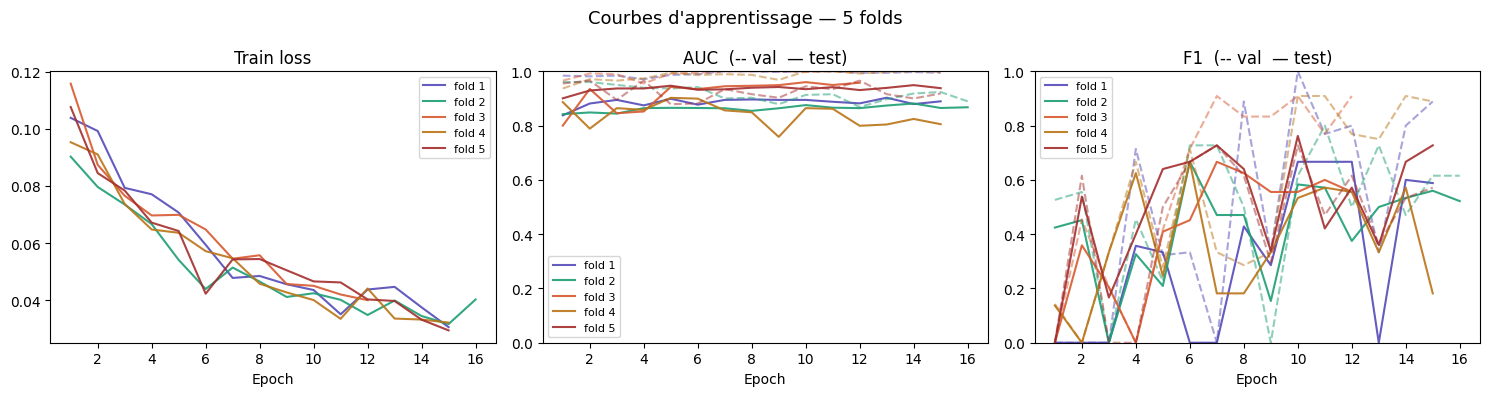


 Meilleurs scores moyens sur 5 folds :
   Val  F1  : 0.869  |  Test F1  : 0.686
   Val  AUC : 0.985  |  Test AUC : 0.919

    Performances correctes !


In [24]:
# Courbes d'apprentissages des 5 folds

colors = ["#534AB7", "#1D9E75", "#D85A30", "#BA7517", "#A32D2D"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Courbes d'apprentissage — 5 folds", fontsize=13)

for r in fold_results:
    h  = r["history"]
    ep = np.arange(1, len(h["train_loss"]) + 1)
    c  = colors[r["fold"] - 1]
    lb = f"fold {r['fold']}"

    axes[0].plot(ep, h["train_loss"], color=c, linestyle="-",  alpha=0.9, label=lb)
    axes[1].plot(ep, h["val_auc"],   color=c, linestyle="--", alpha=0.5)
    axes[1].plot(ep, h["test_auc"],  color=c, linestyle="-",  alpha=0.9, label=lb)
    axes[2].plot(ep, h["val_f1"],    color=c, linestyle="--", alpha=0.5)
    axes[2].plot(ep, h["test_f1"],   color=c, linestyle="-",  alpha=0.9, label=lb)

axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[1].set_title("AUC  (-- val  — test)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[2].set_title("F1  (-- val  — test)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

# Diagnostic
best_val_auc  = np.mean([max(r["history"]["val_auc"])  for r in fold_results])
best_test_auc = np.mean([max(r["history"]["test_auc"]) for r in fold_results])
best_val_f1   = np.mean([max(r["history"]["val_f1"])   for r in fold_results])
best_test_f1  = np.mean([max(r["history"]["test_f1"])  for r in fold_results])

print(f"\n Meilleurs scores moyens sur 5 folds :")
print(f"   Val  F1  : {best_val_f1:.3f}  |  Test F1  : {best_test_f1:.3f}")
print(f"   Val  AUC : {best_val_auc:.3f}  |  Test AUC : {best_test_auc:.3f}")

gap_auc = best_val_auc - best_test_auc
if gap_auc > 0.10:
    print(f"\n    Écart val/test AUC = {gap_auc:.3f} → possible overfitting sur la val")
elif best_test_f1 < 0.4:
    print(f"\n    F1 test encore bas : déséquilibre ou manque de données résistants")
else:
    print(f"\n    Performances correctes !")

In [25]:
# Ré-entraîne le modèle final sur tout le training set

# Oversampling sur tout le dataset
all_labels_full    = np.array([id_to_y[load_pt(dataset.files[i])[0]] for i in range(n)])
class_counts_full  = np.bincount(all_labels_full)
sample_weights_full = 1.0 / class_counts_full[all_labels_full]

sampler_full = WeightedRandomSampler(
    weights=torch.tensor(sample_weights_full, dtype=torch.float),
    num_samples=len(all_labels_full),
    replacement=True
)

full_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler_full,
    collate_fn=mil_collate
)

print(f"   Total génomes  : {n}")
print(f"   Résistants     : {int(all_labels_full.sum())} ({all_labels_full.mean():.1%})")
print(f"   Sensibles      : {int(len(all_labels_full) - all_labels_full.sum())}")

# modèle final from scratch 
set_seed(SEED)
model_final = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
crit_final  = FocalLoss(alpha=0.85, gamma=2.0)
optim_final = optim.AdamW(model_final.parameters(), lr=LR, weight_decay=1e-2)
sched_final = optim.lr_scheduler.ReduceLROnPlateau(optim_final, mode="min", factor=0.5, patience=3)

# Paramètres plateau de loss
PATIENCE_FINAL = 5        # nb d'époques stables avant arrêt
MIN_DELTA      = 0.001    # amélioration minimale considérée
MAX_EPOCHS     = 50      

prev_loss      = float("inf")
patience_ctr   = 0
best_loss      = float("inf")
best_state     = None
final_history  = {"train_loss": []}

print(f"\n   Critère d'arrêt : plateau loss (patience={PATIENCE_FINAL}, delta={MIN_DELTA})")
print(f"   Max époques     : {MAX_EPOCHS}\n")
print(f"{'Epoch':>5} | {'loss':>8} | {'amélioration':>12} | {'patience':>8}")
print("-" * 45)

# Boucle d'entraînement 
for epoch in range(1, MAX_EPOCHS + 1):
    model_final.train()
    total_loss, n_batches = 0.0, 0

    for Xpad, mask, y, _ in full_loader:
        Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
        optim_final.zero_grad()
        logits, _ = model_final(Xpad, mask)
        loss = crit_final(logits, y)
        loss.backward()
        optim_final.step()
        total_loss += float(loss.item())
        n_batches  += 1

    epoch_loss = total_loss / max(n_batches, 1)
    final_history["train_loss"].append(epoch_loss)
    sched_final.step(epoch_loss)

    # Sauvegarde le meilleur état
    if epoch_loss < best_loss:
        best_loss  = epoch_loss
        best_state = {k: v.detach().cpu().clone()
                      for k, v in model_final.state_dict().items()}

    # Critère plateau parce que y a pas de val donc pas de earlystopping
    amelioration = abs(prev_loss - epoch_loss)
    if amelioration < MIN_DELTA:
        patience_ctr += 1
        flag = f"  {patience_ctr}/{PATIENCE_FINAL}"
    else:
        patience_ctr = 0
        flag = " 0/5 "

    print(f"{epoch:5d} | {epoch_loss:8.4f} | {amelioration:12.5f} | {flag}")

    # Arrêt si plateau détecté
    if patience_ctr >= PATIENCE_FINAL:
        print(f"\n⏹  Plateau détecté — arrêt à l'époque {epoch}")
        print(f"   Loss stable depuis {PATIENCE_FINAL} époques (delta < {MIN_DELTA})")
        break

    prev_loss = epoch_loss

# Restorer meilleur état 
if best_state is not None:
    model_final.load_state_dict(best_state)
    print(f" Meilleur état restauré (loss = {best_loss:.4f})")

   Total génomes  : 907
   Résistants     : 53 (5.8%)
   Sensibles      : 854

   Critère d'arrêt : plateau loss (patience=5, delta=0.001)
   Max époques     : 50

Epoch |     loss | amélioration | patience
---------------------------------------------
    1 |   0.1024 |          inf |  0/5 
    2 |   0.0815 |      0.02085 |  0/5 
    3 |   0.0841 |      0.00252 |  0/5 
    4 |   0.0680 |      0.01609 |  0/5 
    5 |   0.0657 |      0.00227 |  0/5 
    6 |   0.0562 |      0.00946 |  0/5 
    7 |   0.0521 |      0.00414 |  0/5 
    8 |   0.0529 |      0.00080 |   1/5
    9 |   0.0438 |      0.00910 |  0/5 
   10 |   0.0403 |      0.00349 |  0/5 
   11 |   0.0312 |      0.00914 |  0/5 
   12 |   0.0409 |      0.00977 |  0/5 
   13 |   0.0367 |      0.00426 |  0/5 
   14 |   0.0364 |      0.00023 |   1/5
   15 |   0.0349 |      0.00158 |  0/5 
   16 |   0.0317 |      0.00315 |  0/5 
   17 |   0.0295 |      0.00225 |  0/5 
   18 |   0.0277 |      0.00178 |  0/5 
   19 |   0.0237 |      0.0

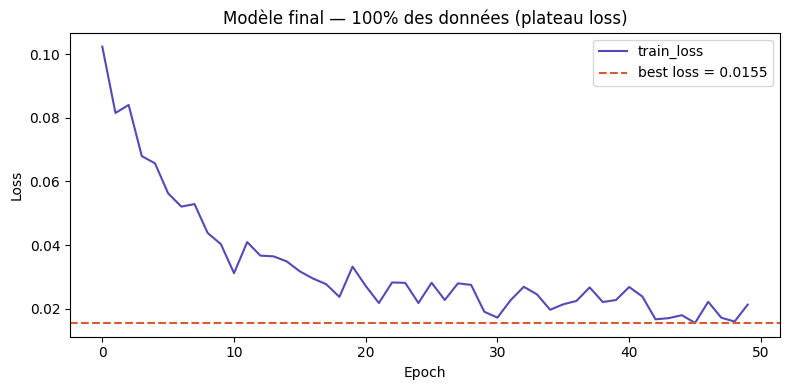


 Résumé entraînement final :
   Nb époques réelles : 50
   Loss initiale      : 0.1024
   Loss finale        : 0.0213
   Meilleure loss     : 0.0155

 Modèle sauvegardé → best_model_final.pt


In [26]:
# courbes d'apprentissages du modèle final

plt.figure(figsize=(8, 4))
plt.plot(final_history["train_loss"], color="#534AB7", label="train_loss")
plt.axhline(y=best_loss, color="#D85A30", linestyle="--",
            label=f"best loss = {best_loss:.4f}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modèle final — 100% des données (plateau loss)")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curve_final.png", dpi=150)
plt.show()

# Résumé 
print(f"\n Résumé entraînement final :")
print(f"   Nb époques réelles : {len(final_history['train_loss'])}")
print(f"   Loss initiale      : {final_history['train_loss'][0]:.4f}")
print(f"   Loss finale        : {final_history['train_loss'][-1]:.4f}")
print(f"   Meilleure loss     : {best_loss:.4f}")

# Sauvegarde
torch.save(model_final.state_dict(), "best_model_final.pt")
print(f"\n Modèle sauvegardé → best_model_final.pt")

# Remplace model pour la validation RGI
model = model_final

In [27]:
# Évalue le modèle final sur toutes les données
# Ce n'est pas un vrai test set : le modèle a vu ces données
# C'est juste pour vérifier que le modèle n'est pas cassé

full_eval_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=mil_collate
)

y_all, prob_all = get_probs(model_final, full_eval_loader)
metrics_train   = compute_metrics(y_all, prob_all, threshold=0.5)

print(" Métriques sur 100% des données (indicatif) :")
print(f"   AUC : {metrics_train['auc']:.3f}")
print(f"   F1  : {metrics_train['f1']:.3f}")
print(f"   Acc : {metrics_train['acc']:.3f}")
print(f"\n  Ces métriques sont optimistes car le modèle")
print(f"   a été entraîné sur ces mêmes données")
print(f"\n Métriques fiables → cross-val : AUC={np.mean([r['test_auc'] for r in fold_results]):.3f} ± {np.std([r['test_auc'] for r in fold_results]):.3f}")

 Métriques sur 100% des données (indicatif) :
   AUC : 1.000
   F1  : 1.000
   Acc : 1.000

  Ces métriques sont optimistes car le modèle
   a été entraîné sur ces mêmes données

 Métriques fiables → cross-val : AUC=0.901 ± 0.034


In [39]:
@torch.no_grad()
def get_top_attention_proteins(model, loader, top_k=10):
    model.eval()
    results = []
    for Xpad, mask, y, gids in loader:
        Xpad, mask    = Xpad.to(device), mask.to(device)
        logits, alpha = model(Xpad, mask)
        probs         = torch.sigmoid(logits).cpu().numpy()
 
        for i, gid in enumerate(gids):
            n_prot  = int(mask[i].sum().item())
            attn    = alpha[i, :n_prot].cpu().numpy()
            top_idx = np.argsort(attn)[::-1][:top_k]
            results.append({
                "genome_id":             gid,
                "true_label":            int(y[i].item()),
                "predicted_prob":        float(probs[i]),
                "n_proteins":            n_prot,
                "top_protein_indices":   top_idx.tolist(),
                "top_attention_weights": attn[top_idx].tolist(),
                "attn_entropy":          float(-np.sum(attn * np.log(attn + 1e-12))),  # entropie = concentration
            })
    return results
 
top_attn = get_top_attention_proteins(model, full_eval_loader, top_k=10)
    
# Affichage top protéines pour les génomes résistants
resistant_results = [r for r in top_attn if r["true_label"] == 1]
print(f"\n Top protéines pour les génomes RÉSISTANTS ({len(resistant_results)} génomes) :")
 
for r in resistant_results[:3]:
    print(f"\n  Genome : {r['genome_id']}  P(resistant)={r['predicted_prob']:.3f}  "
          f"nb_proteins={r['n_proteins']}")
    for rank, (idx, w) in enumerate(
        zip(r["top_protein_indices"], r["top_attention_weights"]), 1
    ):
        print(f"    Top {rank:2d} | protein index {idx:5d} | weight {w:.5f}")


 Top protéines pour les génomes RÉSISTANTS (53 génomes) :

  Genome : 1328437.3  P(resistant)=0.871  nb_proteins=5202
    Top  1 | protein index  4335 | weight 0.00245
    Top  2 | protein index  3888 | weight 0.00223
    Top  3 | protein index   735 | weight 0.00219
    Top  4 | protein index  4431 | weight 0.00216
    Top  5 | protein index  4564 | weight 0.00188
    Top  6 | protein index  1149 | weight 0.00185
    Top  7 | protein index  4565 | weight 0.00180
    Top  8 | protein index  5088 | weight 0.00170
    Top  9 | protein index  3605 | weight 0.00164
    Top 10 | protein index  2893 | weight 0.00155

  Genome : 1328438.3  P(resistant)=0.918  nb_proteins=5191
    Top  1 | protein index  4775 | weight 0.00301
    Top  2 | protein index  4450 | weight 0.00241
    Top  3 | protein index   937 | weight 0.00232
    Top  4 | protein index  4871 | weight 0.00219
    Top  5 | protein index  5094 | weight 0.00197
    Top  6 | protein index  5188 | weight 0.00194
    Top  7 | protein 

## Comparaison des 3 loss functions

In [30]:
# Comparaison des 3 loss functions (cross-val 5-fold)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Définition des 3 options
def get_criterion(option, train_labels, device):
    n_pos = float(train_labels.sum())
    n_neg = float(len(train_labels) - n_pos)
    pw    = n_neg / max(n_pos, 1.0)

    if option == "A":
        return FocalLoss(alpha=0.85, gamma=2.0)
    elif option == "B":
        return nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pw], dtype=torch.float32, device=device)
        )
    elif option == "C":
        class FocalLossWeighted(nn.Module):
            def __init__(self, alpha, gamma, pw):
                super().__init__()
                self.alpha = alpha
                self.gamma = gamma
                self.pw    = pw
            def forward(self, logits, targets):
                bce  = F.binary_cross_entropy_with_logits(
                    logits, targets,
                    pos_weight=torch.tensor([self.pw], device=logits.device),
                    reduction='none'
                )
                pt   = torch.exp(-bce)
                loss = self.alpha * (1 - pt) ** self.gamma * bce
                return loss.mean()
        return FocalLossWeighted(alpha=0.85, gamma=2.0, pw=pw)

# Boucle sur les 3 options
all_results = {}

for option in ["A", "B", "C"]:
    print(f"\n{'='*65}")
    print(f"  Option {option} : {'FocalLoss(alpha=0.85, gamma=2.0)' if option=='A' else 'BCEWithLogitsLoss(pos_weight)' if option=='B' else 'FocalLoss + pos_weight combinés'}")
    print(f"{'='*65}")
    print(f"{'Fold':>4} | {'val_auc':>7} {'val_f1':>6} | {'te_auc':>7} {'te_f1':>6} | {'seuil':>5} | {'te_f1_opt':>9}")
    print("-" * 65)

    fold_results = []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(np.arange(n), all_labels), 1):

        # Split
        train_idx, val_idx = train_test_split(
            train_val_idx, test_size=0.1/0.9,
            stratify=all_labels[train_val_idx], random_state=SEED
        )

        train_ds = Subset(dataset, train_idx)
        val_ds   = Subset(dataset, val_idx)
        test_ds  = Subset(dataset, test_idx)

        # Oversampling
        train_labels   = all_labels[train_idx]
        class_counts   = np.bincount(train_labels)
        sample_weights = 1.0 / class_counts[train_labels]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(train_labels),
            replacement=True
        )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=mil_collate)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)
        test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   collate_fn=mil_collate)

        # Modèle + criterion 
        fold_model     = GatedAttentionMIL(emb_dim, attn_dim=ATTN_DIM, hidden=HIDDEN, dropout=DROPOUT).to(device)
        fold_criterion = get_criterion(option, train_labels, device)
        fold_optimizer = optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-2)
        fold_scheduler = optim.lr_scheduler.ReduceLROnPlateau(fold_optimizer, mode="max", factor=0.5, patience=2)
        fold_early_stop= EarlyStopping(patience=5, min_delta=0.001)

        # Entraînement 
        for epoch in range(1, EPOCHS + 1):
            fold_model.train()
            for Xpad, mask, y, _ in train_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                fold_optimizer.zero_grad()
                logits, _ = fold_model(Xpad, mask)
                loss = fold_criterion(logits, y)
                loss.backward()
                fold_optimizer.step()

            val_m = evaluate(fold_model, val_loader)
            score = 0.5 * (val_m["auc"] or 0) + 0.5 * (val_m["f1"] or 0)
            fold_scheduler.step(score)
            fold_early_stop(score, fold_model)
            if fold_early_stop.stop:
                break

        # Évaluation
        if fold_early_stop.best_state:
            fold_model.load_state_dict(fold_early_stop.best_state)

        val_y,  val_prob  = get_probs(fold_model, val_loader)
        test_y, test_prob = get_probs(fold_model, test_loader)

        best_thr = find_best_threshold(val_y, val_prob)
        val_m    = compute_metrics(val_y,  val_prob, threshold=0.5)
        test_def = compute_metrics(test_y, test_prob, threshold=0.5)
        test_opt = compute_metrics(test_y, test_prob, threshold=best_thr)

        print(
            f"{fold:>4} | {val_m['auc'] or 0:>7.3f} {val_m['f1']:>6.3f} | "
            f"{test_def['auc'] or 0:>7.3f} {test_def['f1']:>6.3f} | "
            f"{best_thr:>5.2f} | {test_opt['f1']:>9.3f}"
        )

        fold_results.append({
            "val_auc":     val_m["auc"]    or 0,
            "val_f1":      val_m["f1"],
            "test_auc":    test_def["auc"] or 0,
            "test_f1":     test_def["f1"],
            "test_f1_opt": test_opt["f1"],
        })

    # Résumé par option
    print("-" * 65)
    for m in ["val_auc", "val_f1", "test_auc", "test_f1", "test_f1_opt"]:
        vals = [r[m] for r in fold_results]
        print(f"   {m:>12} : {np.mean(vals):.3f} ± {np.std(vals):.3f}")

    all_results[option] = fold_results

# Comparaison finale des 3 options
print(f"\n{'='*65}")
print(f"  COMPARAISON FINALE — test_f1_opt (seuil optimal)")
print(f"{'='*65}")
print(f"{'Option':>8} | {'test_f1_opt':>11} | {'test_auc':>8} | {'val_f1':>6}")
print("-" * 45)
for option in ["A", "B", "C"]:
    r   = all_results[option]
    f1  = np.mean([x["test_f1_opt"] for x in r])
    auc = np.mean([x["test_auc"]    for x in r])
    vf1 = np.mean([x["val_f1"]      for x in r])
    print(f"{'Option '+option:>8} | {f1:>11.3f} | {auc:>8.3f} | {vf1:>6.3f}")

best_option = max(["A","B","C"], key=lambda o: np.mean([x["test_f1_opt"] for x in all_results[o]]))
print(f"\n  Meilleure option : {best_option}")


  Option A : FocalLoss(alpha=0.85, gamma=2.0)
Fold | val_auc val_f1 |  te_auc  te_f1 | seuil | te_f1_opt
-----------------------------------------------------------------
   1 |   0.997  0.800 |   0.859  0.353 |  0.49 |     0.444
   2 |   0.929  0.727 |   0.861  0.545 |  0.50 |     0.545
   3 |   0.995  0.909 |   0.950  0.533 |  0.52 |     0.533
   4 |   0.979  0.800 |   0.827  0.333 |  0.51 |     0.333
   5 |   0.968  0.800 |   0.901  0.667 |  0.71 |     0.706
-----------------------------------------------------------------
        val_auc : 0.974 ± 0.025
         val_f1 : 0.807 ± 0.058
       test_auc : 0.880 ± 0.042
        test_f1 : 0.486 ± 0.126
    test_f1_opt : 0.512 ± 0.123

  Option B : BCEWithLogitsLoss(pos_weight)
Fold | val_auc val_f1 |  te_auc  te_f1 | seuil | te_f1_opt
-----------------------------------------------------------------
   1 |   0.953  0.164 |   0.845  0.191 |  0.95 |     0.400
   2 |   0.937  0.357 |   0.865  0.316 |  0.96 |     0.500
   3 |   0.995  0.66

## Partie 2 : Validation Biologique RGI

In [31]:
# Fonction load_labels + load_pt
PT_DIR   = "embeddings_out"
GBK_DIR  = "genomes_gbff"
RGI_DIR  = "rgi_results"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
def load_labels(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"]   = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"]))
 
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()
 
# Charge labels + fichiers
id_to_y   = load_labels(LABELS_PATH)
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
resistant_files  = [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 1]
susceptible_files= [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 0]
 
print(f"Labels chargés")
print(f"Total .pt matchés  : {len(matched)}")
print(f"Résistants         : {len(resistant_files)}")
print(f"Sensibles          : {len(susceptible_files)}")

Labels chargés
Total .pt matchés  : 907
Résistants         : 53
Sensibles          : 854


In [32]:
# IDs dans tes .pt
pt_ids  = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("embeddings_out/*.pt"))

# IDs dans tes résultats RGI
rgi_ids = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("rgi_results/*.txt"))

# IDs dans tes .gbff
gbff_ids = set(os.path.splitext(os.path.basename(f))[0]
               for f in glob.glob("genomes_gbff/*.gbff"))

print(f"IDs dans .pt   : {len(pt_ids)}")
print(f"IDs dans RGI   : {len(rgi_ids)}")
print(f"IDs dans .gbff : {len(gbff_ids)}")

IDs dans .pt   : 1066
IDs dans RGI   : 1066
IDs dans .gbff : 1066


In [33]:
# Parser le .gbff pour extraire les CDS dans l'ordre
 
def load_gbff_annotation(genome_id):
    gbff_file = os.path.join(GBK_DIR, f"{genome_id}.gbff")
    if not os.path.exists(gbff_file):
        print(f"Fichier non trouvé : {gbff_file}")
        return None
    rows = []
    for record in SeqIO.parse(gbff_file, "genbank"):
        for feature in record.features:
            if feature.type != "CDS":
                continue
            rows.append({
                "contig":    record.id,
                "start":     int(feature.location.start),
                "end":       int(feature.location.end),
                "strand":    int(feature.location.strand),
                "locus_tag": feature.qualifiers.get("locus_tag", [""])[0],
                "gene":      feature.qualifiers.get("gene",      [""])[0],
                "product":   feature.qualifiers.get("product",   ["unknown"])[0],
            })
    if not rows:
        print(f"Aucun CDS trouvé")
        return None
    df = pd.DataFrame(rows).reset_index()
    return df.rename(columns={"index": "protein_index"})
 
# Test sur le premier génome disponible
sample_gid = load_pt(all_files[0])[0]
ann_test   = load_gbff_annotation(sample_gid)
 
if ann_test is not None:
    print(f".gbff chargé pour : {sample_gid}")
    print(f"   Nb CDS : {len(ann_test)}")
    print(ann_test[["protein_index","gene","product","start","end"]].head(10))
else:
    print("Problème — vérifie GBK_DIR et le nom des fichiers")

.gbff chargé pour : 1328432.3
   Nb CDS : 4665
   protein_index    gene                                            product  \
0              0    thrA  Bifunctional aspartokinase/homoserine dehydrog...   
1              1    thrB                                  Homoserine kinase   
2              2    thrC                                 Threonine synthase   
3              3                                       hypothetical protein   
4              4    yaaA  DNA-binding and peroxide stress resistance pro...   
5              5    alsT                    Amino-acid carrier protein AlsT   
6              6  talB_1                                    Transaldolase B   
7              7     mog                  Molybdopterin adenylyltransferase   
8              8    satP            Succinate-acetate/proton symporter SatP   
9              9                                       hypothetical protein   

   start    end  
0    335   2798  
1   2799   3732  
2   3732   5019  
3   5232   

In [34]:
# Affichage des colonnes du fichier RGI
import pandas as pd, os

test_gid = load_pt(resistant_files[0])[0]
rgi_file = os.path.join(RGI_DIR, f"{test_gid}.txt")

df = pd.read_csv(rgi_file, sep="\t")
print(f"Colonnes disponibles :")
for col in df.columns:
    print(f"  → '{col}'")

print(f"\nPremières lignes :")
print(df.head(3).to_string())

Colonnes disponibles :
  → 'ORF_ID'
  → 'Contig'
  → 'Start'
  → 'Stop'
  → 'Orientation'
  → 'Cut_Off'
  → 'Pass_Bitscore'
  → 'Best_Hit_Bitscore'
  → 'Best_Hit_ARO'
  → 'Best_Identities'
  → 'ARO'
  → 'Model_type'
  → 'SNPs_in_Best_Hit_ARO'
  → 'Other_SNPs'
  → 'Drug Class'
  → 'Resistance Mechanism'
  → 'AMR Gene Family'
  → 'Predicted_DNA'
  → 'Predicted_Protein'
  → 'CARD_Protein_Sequence'
  → 'Percentage Length of Reference Sequence'
  → 'ID'
  → 'Model_ID'
  → 'Nudged'
  → 'Note'
  → 'Hit_Start'
  → 'Hit_End'
  → 'Antibiotic'
  → 'AST_Source'

Premières lignes :
                                                                                                                               ORF_ID        Contig   Start    Stop Orientation  Cut_Off  Pass_Bitscore  Best_Hit_Bitscore           Best_Hit_ARO  Best_Identities      ARO             Model_type SNPs_in_Best_Hit_ARO Other_SNPs                                                                                                      

In [35]:
# Parser les résultats RGI
 
def load_rgi_meropenem(genome_id):
    rgi_file = os.path.join(RGI_DIR, f"{genome_id}.txt")
    if not os.path.exists(rgi_file):
        return None

    df = pd.read_csv(rgi_file, sep="\t")

    # Garde Perfect + Strict uniquement
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])].copy()
    if len(df) == 0:
        return None

    # ── Filtre méropénème sur "Drug Class" ───
    mask = df["Drug Class"].str.lower().str.contains(
        "carbapenem|penem", na=False
    )
    df = df[mask].copy()
    if len(df) == 0:
        return None

    # Parse start/stop depuis Start/Stop
    df["rgi_start"] = df["Start"].astype(int)
    df["rgi_stop"]  = df["Stop"].astype(int)

    return df.reset_index(drop=True)

# Test sur le premier génome résistant
test_gid = load_pt(resistant_files[0])[0]
rgi_test = load_rgi_meropenem(test_gid)

print(f"Test RGI méropénème sur : {test_gid}")
if rgi_test is not None:
    print(f"   Nb gènes carbapénème détectés : {len(rgi_test)}")
    print(rgi_test[["Best_Hit_ARO", "Drug Class", "Cut_Off", "Best_Identities"]].to_string(index=False))
else:
    print("Aucun gène carbapénème trouvé")
    # Diagnostic — affiche tous les Drug Class trouvés
    df_all = pd.read_csv(os.path.join(RGI_DIR, f"{test_gid}.txt"), sep="\t")
    df_all = df_all[df_all["Cut_Off"].isin(["Perfect","Strict"])]
    print(f"\n   Tous les Drug Class trouvés :")
    for dc in df_all["Drug Class"].unique():
        print(f"     → {dc}")

Test RGI méropénème sur : 1328437.3
   Nb gènes carbapénème détectés : 3
                                                        Best_Hit_ARO                                                                                                                                                                                                        Drug Class Cut_Off  Best_Identities
                                                                marA fluoroquinolone antibiotic; monobactam; carbapenem; cephalosporin; glycylcycline; penicillin beta-lactam; tetracycline antibiotic; rifamycin antibiotic; phenicol antibiotic; disinfecting agents and antiseptics Perfect            100.0
                                                               KPC-2                                                                                                                                                     monobactam; carbapenem; cephalosporin; penicillin beta-lactam Perfect            100.0
Escherichia col

In [36]:
# Croiser RGI + .gbff → trouver l'indice protéine
 
def find_resistance_indices(genome_id):
    ann    = load_gbff_annotation(genome_id)
    rgi_df = load_rgi_meropenem(genome_id)
    if ann is None or rgi_df is None:
        return []
    results = []
    for _, rgi_gene in rgi_df.iterrows():
        rgi_start = int(rgi_gene["rgi_start"])
        rgi_stop  = int(rgi_gene["rgi_stop"])
        best_idx, best_overlap, best_row = None, 0, None
        for _, cds in ann.iterrows():
            overlap = max(0,
                min(rgi_stop, cds["end"]) - max(rgi_start, cds["start"]))
            if overlap > best_overlap:
                best_overlap = overlap
                best_idx     = int(cds["protein_index"])
                best_row     = cds
        if best_idx is not None and best_row is not None:
            results.append({
                "protein_index":        best_idx,
                "aro_name":             rgi_gene.get("Best_Hit_ARO",         ""),
                "drug_class":           rgi_gene.get("Drug Class",           ""),  
                "resistance_mechanism": rgi_gene.get("Resistance Mechanism", ""),  
                "cut_off":              rgi_gene.get("Cut_Off",              ""),
                "identity":             rgi_gene.get("Best_Identities",      0),
                "gene":                 best_row["gene"],
                "product":              best_row["product"],
                "locus_tag":            best_row["locus_tag"],
                "overlap_bp":           best_overlap,
            })
    return results

# Test sur le premier génome résistant
res_genes = find_resistance_indices(test_gid)

print(f"Croisement RGI + .gbff pour : {test_gid}\n")
if res_genes:
    for g in res_genes:
        print(f"   → {g['aro_name']:40s} | indice : {g['protein_index']:5d} | "
              f"id : {g['identity']:.1f}% | {g['drug_class'][:40]}")
else:
    print("Aucun gène méropénème trouvé")

Croisement RGI + .gbff pour : 1328437.3

   → marA                                     | indice :   608 | id : 100.0% | fluoroquinolone antibiotic; monobactam; 
   → KPC-2                                    | indice :  2531 | id : 100.0% | monobactam; carbapenem; cephalosporin; p
   → Escherichia coli soxS with mutation conferring antibiotic resistance | indice :  1908 | id : 100.0% | fluoroquinolone antibiotic; monobactam; 


In [37]:
# RGI méropénème sur TOUS les génomes + stockage

import json
from tqdm import tqdm

all_res_genes = {}   
stats = {"avec_genes": 0, "sans_genes": 0, "sans_rgi": 0, "sans_gbff": 0}

print(f"Analyse de {len(matched)} génomes...\n")

for fp in tqdm(matched):
    gid = load_pt(fp)[0]

    # Vérifie que les fichiers existent
    rgi_file  = os.path.join(RGI_DIR,  f"{gid}.txt")
    gbff_file = os.path.join(GBK_DIR,  f"{gid}.gbff")

    if not os.path.exists(rgi_file):
        stats["sans_rgi"] += 1
        continue
    if not os.path.exists(gbff_file):
        stats["sans_gbff"] += 1
        continue

    # Trouve les gènes de résistance méropénème
    res_genes = find_resistance_indices(gid)

    if res_genes:
        all_res_genes[gid] = res_genes
        stats["avec_genes"] += 1
    else:
        all_res_genes[gid] = []
        stats["sans_genes"] += 1

# Résumé 
print(f"\n Résumé :")
print(f"   Génomes analysés              : {len(matched)}")
print(f"   Avec gènes carbapénème        : {stats['avec_genes']}")
print(f"   Sans gènes carbapénème        : {stats['sans_genes']}")
print(f"   Sans fichier RGI              : {stats['sans_rgi']}")
print(f"   Sans fichier .gbff            : {stats['sans_gbff']}")

# Gènes les plus fréquents
from collections import Counter
all_gene_names = [g["aro_name"] for genes in all_res_genes.values() for g in genes]
gene_counts    = Counter(all_gene_names).most_common(15)

print(f"\n Top 15 gènes carbapénème les plus fréquents :")
for gene, count in gene_counts:
    bar = "█" * int(count / max(gene_counts[0][1], 1) * 20)
    print(f"   {gene:45s} | {count:4d} génomes  {bar}")

# Résistants vs sensibles
print(f"\n Gènes trouvés selon le phénotype :")
for label, label_name in [(1, "Résistants"), (0, "Sensibles")]:
    gids_label = [load_pt(fp)[0] for fp in matched if id_to_y[load_pt(fp)[0]] == label]
    genes_label = [g["aro_name"] for gid in gids_label
                   if gid in all_res_genes
                   for g in all_res_genes[gid]]
    counts = Counter(genes_label).most_common(5)
    print(f"\n   {label_name} — top 5 gènes :")
    for gene, count in counts:
        print(f"     → {gene:40s} : {count} génomes")

# Sauvegarde JSON
with open("tesst_resistance_genes_all.json", "w") as f:
    json.dump(all_res_genes, f, indent=2)
print(f"\n Sauvegardé → resistance_genes_all.json")

# Sauvegarde CSV
rows = []
for gid, genes in all_res_genes.items():
    for g in genes:
        rows.append({
            "genome_id":  gid,
            "true_label": id_to_y.get(gid, -1),
            **g
        })

df_all_genes = pd.DataFrame(rows)
#df_all_genes.to_csv("tesst_resistance_genes_all.csv", index=False)
#print(f" Sauvegardé → resistance_genes_all.csv ({len(df_all_genes)} lignes)")
print(df_all_genes[["genome_id","true_label","aro_name",
                     "protein_index","identity","cut_off"]].head(20).to_string(index=False))

Analyse de 907 génomes...



100%|██████████| 907/907 [12:48<00:00,  1.18it/s]



 Résumé :
   Génomes analysés              : 907
   Avec gènes carbapénème        : 899
   Sans gènes carbapénème        : 8
   Sans fichier RGI              : 0
   Sans fichier .gbff            : 0

 Top 15 gènes carbapénème les plus fréquents :
   Escherichia coli soxS with mutation conferring antibiotic resistance |  892 génomes  ████████████████████
   marA                                          |  884 génomes  ███████████████████
   TolC                                          |  548 génomes  ████████████
   CMY-2                                         |  172 génomes  ███
   CTX-M-27                                      |   27 génomes  
   KPC-2                                         |   16 génomes  
   KPC-3                                         |    9 génomes  
   NDM-1                                         |    8 génomes  
   NDM-5                                         |    8 génomes  
   Klebsiella pneumoniae KpnG                    |    4 génomes  
   Klebsiella p

In [ ]:
# Validation finale : poids attention vs gènes CARD

full_eval_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=mil_collate
)

@torch.no_grad()
def validate_attention_vs_resistance(model, loader, all_res_genes, top_k=50):
    model.eval()
    results = []

    for Xpad, mask, y, gids in loader:
        Xpad, mask    = Xpad.to(device), mask.to(device)
        logits, alpha = model(Xpad, mask)
        probs         = torch.sigmoid(logits).cpu().numpy()

        for i, gid in enumerate(gids):
            n_prot  = int(mask[i].sum().item())
            attn    = alpha[i, :n_prot].cpu().numpy()
            ranks   = n_prot - np.argsort(np.argsort(attn))
            top_idx = np.argsort(attn)[::-1][:top_k]

            res_genes = all_res_genes.get(gid, [])

            gene_validation = []
            for g in res_genes:
                idx = g["protein_index"]
                if idx < n_prot:
                    gene_validation.append({
                        "aro_name":             g["aro_name"],
                        "protein_index":        idx,
                        "attention_weight":     float(attn[idx]),
                        "attention_rank":       int(ranks[idx]),
                        "attention_percentile": float(100 * (1 - ranks[idx] / n_prot)),
                        "in_top_k":             int(ranks[idx]) <= top_k,
                        "drug_class":           g["drug_class"],
                        "identity":             g["identity"],
                    })

            results.append({
                "genome_id":        gid,
                "true_label":       int(y[i].item()),
                "predicted_prob":   float(probs[i]),
                "n_proteins":       n_prot,
                "top_k_indices":    top_idx.tolist(),
                "top_k_weights":    attn[top_idx].tolist(),
                "resistance_genes": gene_validation,
            })

    return results

# Sur 100% des données
TOP_K      = 50
validation = validate_attention_vs_resistance(
    model, full_eval_loader, all_res_genes, top_k=TOP_K
)
print(f" Validation terminée sur {len(validation)} génomes")

# Génomes résistants
print("\n" + "=" * 80)
print(" VALIDATION BIOLOGIQUE — GÉNOMES RÉSISTANTS")
print("=" * 80)

resistant_validation = [r for r in validation if r["true_label"] == 1]
print(f"   Nb génomes résistants : {len(resistant_validation)}\n")

for r in resistant_validation:
    print(f"\n  Genome : {r['genome_id']}  |  "
          f"P(resistant) = {r['predicted_prob']:.3f}  |  "
          f"{r['n_proteins']} protéines")

    if not r["resistance_genes"]:
        print("  Aucun gène CARD trouvé par RGI")
        continue

    print(f"  {'Gène CARD':40s} | {'Rang':>10} | {'Top %':>7} | {'Poids':>12} | {'✓':>5}")
    print(f"  {'-'*40}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*5}")

    for g in sorted(r["resistance_genes"],
                    key=lambda x: x["attention_rank"]):
        flag = "✅" if g["in_top_k"] else "❌"
        print(
            f"  {g['aro_name']:40s} | "
            f"{g['attention_rank']:4d}/{r['n_proteins']:4d} | "
            f"{g['attention_percentile']:6.1f}% | "
            f"{g['attention_weight']:.10f} | "
            f"  {flag}"
        )

    # Top-10 global pour comparaison
    print(f"\n  Top-10 protéines les plus attentives :")
    for rank, (idx, w) in enumerate(
        zip(r["top_k_indices"][:10], r["top_k_weights"][:10]), 1
    ):
        is_res = any(g["protein_index"] == idx for g in r["resistance_genes"])
        flag   = "  CARD" if is_res else ""
        print(f"    {rank:2d}. protein {idx:5d} | weight {w:.10f}{flag}")

# Résumé statistique

res_genes_R = [g for r in validation
               if r["true_label"] == 1
               for g in r["resistance_genes"]]

res_genes_S = [g for r in validation
               if r["true_label"] == 0
               for g in r["resistance_genes"]]

print(f"\n{'='*80}")
print(f" RÉSUMÉ STATISTIQUE")
print(f"{'='*80}")

if res_genes_R:
    n_top = sum(1 for g in res_genes_R if g["in_top_k"])
    pcts  = [g["attention_percentile"] for g in res_genes_R]

    print(f"\n  Génomes RÉSISTANTS :")
    print(f"    Nb génomes résistants          : {len(resistant_validation)}")
    print(f"    Gènes CARD détectés            : {len(res_genes_R)}")
    print(f"    Dans top-{TOP_K} attention          : {n_top}/{len(res_genes_R)} ({n_top/len(res_genes_R):.1%})")
    print(f"    Percentile moyen               : {np.mean(pcts):.1f}%")
    print(f"    Percentile médian              : {np.median(pcts):.1f}%")
    print(f"    Percentile min                 : {np.min(pcts):.1f}%")
    print(f"    Percentile max                 : {np.max(pcts):.1f}%")

    if np.mean(pcts) > 80:
        print("\n     VALIDATION RÉUSSIE — gènes CARD systématiquement attentifs !")
    elif np.mean(pcts) > 60:
        print("\n     Signal modéré")
    else:
        print("\n     Signal faible")

if res_genes_S:
    pcts_s = [g["attention_percentile"] for g in res_genes_S]
    print(f"\n  Génomes SENSIBLES avec gènes CARD :")
    print(f"    Gènes détectés                 : {len(res_genes_S)}")
    print(f"    Percentile moyen               : {np.mean(pcts_s):.1f}%")
    print(f"    → normal si bas : phénotype sensible malgré gène présent")

# Visualisation
if res_genes_R:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Validation biologique — Poids d'attention vs gènes CARD",
                 fontsize=13)

    #  Gauche : distribution des percentiles 
    pcts_R = [g["attention_percentile"] for g in res_genes_R]
    pcts_S = [g["attention_percentile"] for g in res_genes_S] if res_genes_S else []

    axes[0].hist(pcts_R, bins=20, color="#534AB7",
                 alpha=0.7, label=f"Résistants (n={len(pcts_R)})")
    if pcts_S:
        axes[0].hist(pcts_S, bins=20, color="#1D9E75",
                     alpha=0.7, label=f"Sensibles (n={len(pcts_S)})")
    axes[0].axvline(x=80, color="#D85A30", linestyle="--",
                    label="seuil top 20%")
    axes[0].set_xlabel("Percentile d'attention (%)")
    axes[0].set_ylabel("Nb gènes")
    axes[0].set_title("Distribution des percentiles\ndes gènes CARD")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    #  Droite : top gènes CARD dans top-50
    top_genes = [g["aro_name"] for g in res_genes_R if g["in_top_k"]]
    if top_genes:
        from collections import Counter
        gene_counts = Counter(top_genes).most_common(10)
        genes, counts = zip(*gene_counts)
        axes[1].barh(list(genes), list(counts), color="#534AB7")
        axes[1].set_xlabel("Nb génomes où le gène est dans top-50")
        axes[1].set_title("Gènes CARD les plus attentifs\n(top-50)")
        axes[1].invert_yaxis()
        axes[1].grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig("attention_vs_card.png", dpi=150)
    plt.show()